# Análise Estratégica de Incidentes de TI

Notebook com quatro frentes de análise sobre a base de incidentes: cumprimento de OLA/KPI, feature engineering para clusterização, hierarquia de incidentes pai/filho e comparação entre solução por contorno e definitiva. Ao final, os datasets tratados são exportados para uso em modelagem.

Fonte de dados: partições Spark (`part-*.csv`) · Encoding: ISO-8859-1 · Separador: `;`


## Configurações Iniciais

### Configurações a depender do ambiente

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules
ENV_NAME = "☁️ Google Colab" if IN_COLAB else "💻 Ambiente Local (WSL/Jupyter)"

print(f"Detectado: {ENV_NAME}")
print(f"Versão do Python: {sys.version.split()[0]}")

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/1_bronze_data/"
else:
    BASE_PATH = "../1_bronze_data/"


### Importação de Bibliotecas

In [ ]:
import glob
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', font_scale=1.05)

paleta_prioridade = {
    '1 - Crítica':     '#7f1d1d',
    '2 - Alta':        '#c0392b',
    '3 - Média':       '#d68910',
    '4 - Baixa':       '#2471a3',
    '5 - Muito Baixa': '#5d6d7e',
}
paleta_status_ola = {'Cumprido': '#1a5276', 'Violado': '#a93226'}
paleta_solucao = {'Contorno': '#d68910', 'Definitiva': '#1a5276', 'Não Informado': '#95a5a6'}
cor_neutra = '#34495e'

def formata_milhar(ax, eixo='y'):
    fmt = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',', '.'))
    (ax.yaxis if eixo == 'y' else ax.xaxis).set_major_formatter(fmt)

### Importação de Dados

In [ ]:
arquivos_parte = sorted([
    f for f in glob.glob(f'{BASE_PATH}part-*.csv')
    if not f.endswith('.crc') and '_SUCCESS' not in f
])

if not arquivos_parte:
    raise FileNotFoundError(f'Nenhum arquivo "part-*.csv" encontrado em {BASE_PATH}')

df = pd.concat(
    (pd.read_csv(f, sep=';', encoding='ISO-8859-1') for f in arquivos_parte),
    ignore_index=True,
)

print(f'{len(arquivos_parte)} partição(ões) carregada(s) | {df.shape[0]:,} incidentes | {df.shape[1]} colunas'.replace(',', '.'))


In [ ]:
resumo_nulos = (
    df.isna().mean().mul(100).round(1).sort_values(ascending=False).rename('% Nulo')
)
display(resumo_nulos[resumo_nulos > 0].to_frame())
df[['Prioridade', 'Duração', 'Status']].describe(include='all').T

,% Nulo
Incidente Pai,87.70
Solução,87.50
KPI Violado?,79.10
Resolvido,67.20
Tempo_Pos_Resolução,67.20
Produto,63.60
Subcategoria,63.40
Categoria,63.40
Item de configuração,1.50


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Prioridade,122543,5,4 - Baixa,64828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duração,"122,543.00",NaN,NaN,NaN,"248,547.00","2,480,123.47",1.00,263.00,978.00,"4,240.50","88,280,481.00"
Status,122543,4,Sem Intervenção,80373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. OLA / KPI — Cumprimento do Acordo de Nível de Serviço

O Dicionário de Dados define que apenas as prioridades 1, 2 e 3 entram no KPI oficial de SLA, e a base já traz esse cálculo pronto nas colunas `Entrou para KPI?` e `KPI Violado?`. Além dessa métrica contratual, calculamos um OLA operacional mais amplo — aplicando o limite de duração às 5 prioridades — usado como indicador interno de diagnóstico, não como número de risco contratual.

| Prioridade | Limite de Duração |
|---|---|
| 1 - Crítica | 4h |
| 2 - Alta | 4h |
| 3 - Média | 12h |
| 4 - Baixa | 24h |
| 5 - Muito Baixa | 96h |

Regra de elegibilidade do OLA operacional: excluem-se incidentes com `Incidente Pai` preenchido e `Status = "Sem Intervenção"`.


In [ ]:
limites_ola_segundos = {
    '1 - Crítica':     4 * 3600,
    '2 - Alta':        4 * 3600,
    '3 - Média':       12 * 3600,
    '4 - Baixa':       24 * 3600,
    '5 - Muito Baixa': 96 * 3600,
}

elegivel_ola = df['Incidente Pai'].isna() & (df['Status'] != 'Sem Intervenção')
df_ola = df.loc[elegivel_ola].copy()
df_ola['limite_ola_s'] = df_ola['Prioridade'].map(limites_ola_segundos)
df_ola['ola_status'] = np.where(df_ola['Duração'] <= df_ola['limite_ola_s'], 'Cumprido', 'Violado')

print(f'[OLA operacional] elegíveis: {len(df_ola):,} de {len(df):,} ({len(df_ola)/len(df):.1%})'.replace(',', '.'))
print(f'[OLA operacional] cumprimento geral: {(df_ola["ola_status"]=="Cumprido").mean():.1%}')

kpi_oficial = df[df['Entrou para KPI?'] == 'SIM'].copy()
print(f"\n[KPI oficial] elegíveis: {len(kpi_oficial):,} de {len(df):,} ({len(kpi_oficial)/len(df):.1%})".replace(',', '.'))
print(f"[KPI oficial] cumprimento geral: {(kpi_oficial['KPI Violado?']=='NAO').mean():.1%}")

[OLA operacional] elegíveis: 33.608 de 122.543 (27.4%)
[OLA operacional] cumprimento geral: 84.8%

[KPI oficial] elegíveis: 25.602 de 122.543 (20.9%)
[KPI oficial] cumprimento geral: 99.0%


### Validação — recálculo interno vs. KPI oficial

In [ ]:
comparavel = df[
    (df['Entrou para KPI?'] == 'SIM') & (df['Prioridade'].isin(['2 - Alta', '3 - Média']))
].copy()
comparavel['limite_ola_s'] = comparavel['Prioridade'].map(limites_ola_segundos)
comparavel['ola_recalculado'] = np.where(comparavel['Duração'] <= comparavel['limite_ola_s'], 'Cumprido', 'Violado')
comparavel['kpi_oficial_status'] = np.where(comparavel['KPI Violado?'] == 'SIM', 'Violado', 'Cumprido')

# Nota: na base, "Entrou para KPI?" = SIM só ocorre para Prioridade 2 e 3 (Prioridade 1 tem 1 único
# registro na base inteira e não entra no KPI) — o filtro acima é mantido explícito por robustez.
n_comparavel_fmt = f'{len(comparavel):,}'.replace(',', '.')
print(f'Universo comparável (Entrou p/ KPI = SIM, Prioridade 2 ou 3): {n_comparavel_fmt}')

tabela_reconciliacao = pd.crosstab(comparavel['ola_recalculado'], comparavel['kpi_oficial_status'])
display(tabela_reconciliacao)

divergentes = comparavel[comparavel['ola_recalculado'] != comparavel['kpi_oficial_status']]
taxa_div = len(divergentes) / len(comparavel)
print(f'Divergência: {len(divergentes):,} de {len(comparavel):,} casos ({taxa_div:.1%})'.replace(',', '.'))

div = comparavel[(comparavel['ola_recalculado'] == 'Violado') & (comparavel['kpi_oficial_status'] == 'Cumprido')]
razao_estouro = div['Duração'] / div['limite_ola_s']

erro_de_borda = (razao_estouro <= 1.2).mean()
estrutural = (razao_estouro > 1.2).mean()
print(f'Mediana de estouro nos casos divergentes: {razao_estouro.median():.1f}x o limite do OLA.')
print(f'  - Razão ≤ 1,2x (compatível com erro de borda/arredondamento): {erro_de_borda:.1%} dos casos divergentes')
print(f'  - Razão > 1,2x (padrão estrutural, não erro de borda): {estrutural:.1%} dos casos divergentes')
print('A divergência é sistemática (mesmo sentido em praticamente todos os casos), concentrada na Prioridade 3,')
print('e a magnitude típica (dezenas de vezes o limite) descarta erro de borda como explicação principal.')
print('Estouros dessa magnitude sugerem que o KPI oficial usa um relógio de SLA que pausa em estados de espera')
print('(ex.: aguardando cliente, fora de horário comercial), enquanto `Duração` é tempo corrido total.')
print('Hipótese não confirmável com as colunas disponíveis — recomenda-se validar com a área responsável pelo ITSM.')

Universo comparável (Entrou p/ KPI = SIM, Prioridade 2 ou 3): 25.602


kpi_oficial_status,Cumprido,Violado
ola_recalculado,,
Cumprido,21956,1
Violado,3398,247


Divergência: 3.399 de 25.602 casos (13.3%)
Mediana de estouro nos casos divergentes: 27.9x o limite do OLA.
  - Razão ≤ 1,2x (compatível com erro de borda/arredondamento): 2.4% dos casos divergentes
  - Razão > 1,2x (padrão estrutural, não erro de borda): 97.6% dos casos divergentes
A divergência é sistemática (mesmo sentido em praticamente todos os casos), concentrada na Prioridade 3,
e a magnitude típica (dezenas de vezes o limite) descarta erro de borda como explicação principal.
Estouros dessa magnitude sugerem que o KPI oficial usa um relógio de SLA que pausa em estados de espera
(ex.: aguardando cliente, fora de horário comercial), enquanto `Duração` é tempo corrido total.
Hipótese não confirmável com as colunas disponíveis — recomenda-se validar com a área responsável pelo ITSM.


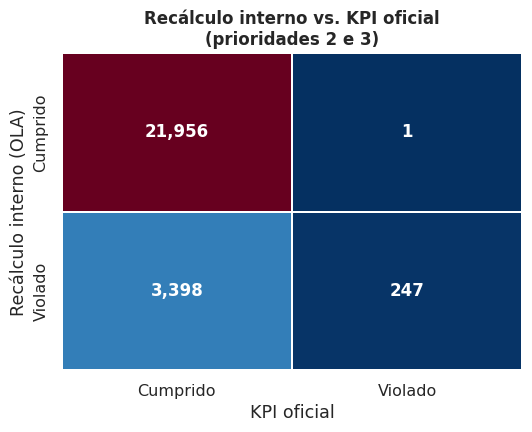

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    tabela_reconciliacao,
    annot=True, fmt=',', cmap='RdBu_r', cbar=False,
    linewidths=1.2, linecolor='white',
    annot_kws={'fontsize': 12, 'fontweight': 'bold'},
    ax=ax,
)
ax.set_title('Recálculo interno vs. KPI oficial\n(prioridades 2 e 3)', fontsize=12, fontweight='bold')
ax.set_xlabel('KPI oficial')
ax.set_ylabel('Recálculo interno (OLA)')
plt.tight_layout()
plt.show()

In [ ]:
# Validação cruzada: a base já traz uma coluna pré-computada pelo pipeline Spark
# ("Diferença_Limite_Duração") com a mesma lógica de Duração - limite operacional.
# Usamos essa coluna independente para confirmar que a fórmula do recálculo está correta.
comparavel['diferenca_propria'] = comparavel['Duração'] - comparavel['limite_ola_s']
bate_formula = np.isclose(comparavel['diferenca_propria'], comparavel['Diferença_Limite_Duração']).mean()

print(f'Fórmula do recálculo confere com a coluna pré-computada Diferença_Limite_Duração em {bate_formula:.1%} dos casos.')
print('Isso descarta erro de fórmula do lado do recálculo: a divergência com `KPI Violado?` não vem de um')
print('cálculo interno equivocado, e sim de uma régua diferente por trás da coluna oficial — reforça a')
print('recomendação de validar o relógio de SLA com a área de ITSM, em vez de desconfiar do próprio recálculo.')

Fórmula do recálculo confere com a coluna pré-computada Diferença_Limite_Duração em 100.0% dos casos.
Isso descarta erro de fórmula do lado do recálculo: a divergência com `KPI Violado?` não vem de um
cálculo interno equivocado, e sim de uma régua diferente por trás da coluna oficial — reforça a
recomendação de validar o relógio de SLA com a área de ITSM, em vez de desconfiar do próprio recálculo.


### Cumprimento por prioridade (OLA operacional)

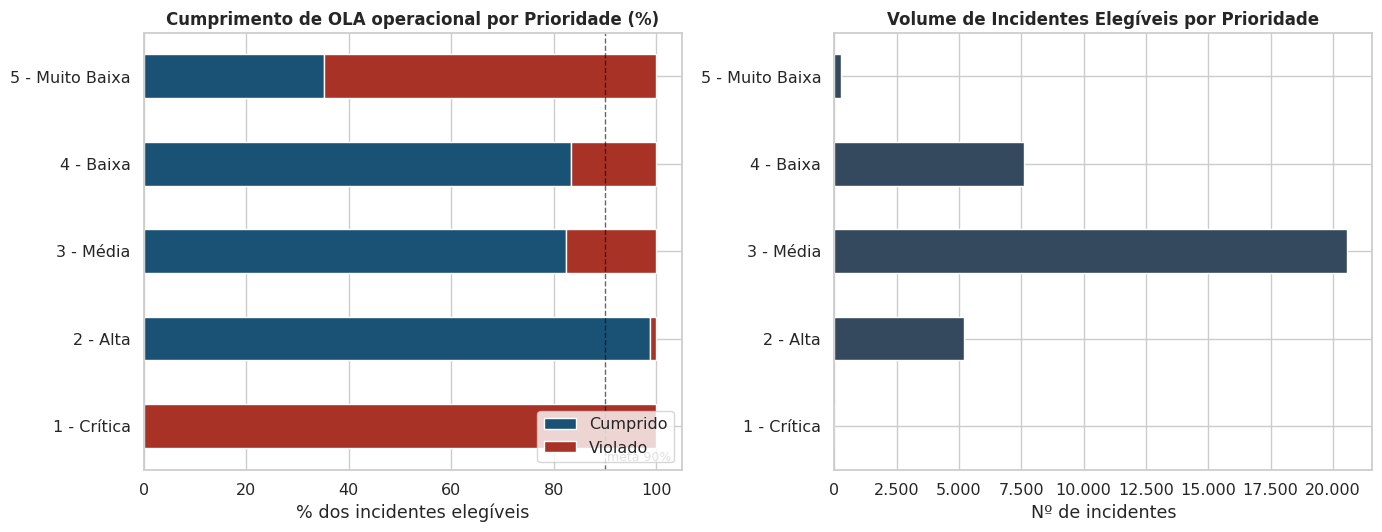

,Nº incidentes
Produto,
lhco,7083
lcem,3071
lsin,2373
lhvp,1183
lrev,1071
lcsi,1046
lsaa,527
lrdo,485
lssl,426


In [ ]:
resumo_prioridade = (
    df_ola.groupby('Prioridade')['ola_status']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .reindex(limites_ola_segundos.keys())
    .mul(100)
)
volumetria_prioridade = df_ola['Prioridade'].value_counts().reindex(limites_ola_segundos.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

resumo_prioridade[['Cumprido', 'Violado']].plot(
    kind='barh', stacked=True, ax=axes[0],
    color=[paleta_status_ola['Cumprido'], paleta_status_ola['Violado']],
)
axes[0].set_title('Cumprimento de OLA operacional por Prioridade (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('% dos incidentes elegíveis')
axes[0].set_ylabel('')
axes[0].legend(title='', loc='lower right')
axes[0].axvline(90, color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[0].text(90.5, -0.4, 'meta 90%', fontsize=9, alpha=0.7)

volumetria_prioridade.plot(kind='barh', ax=axes[1], color=cor_neutra)
axes[1].set_title('Volume de Incidentes Elegíveis por Prioridade', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nº de incidentes')
axes[1].set_ylabel('')
formata_milhar(axes[1], eixo='x')

plt.tight_layout()
plt.show()

display(df_ola.loc[df_ola['Prioridade'] == '3 - Média', 'Produto'].value_counts().head(10).to_frame('Nº incidentes'))

### Exposição de horas e custo operacional estimado

In [ ]:
violados = df_ola[df_ola['ola_status'] == 'Violado'].copy()
violados['horas_estouro'] = (violados['Duração'] - violados['limite_ola_s']) / 3600

print(f'Incidentes com OLA operacional violado: {len(violados):,}'.replace(',', '.'))
print(f'Exposição total de horas além do limite: {violados["horas_estouro"].sum():,.0f} h'.replace(',', '.'))
print(f'Estouro típico (mediana) por incidente violado: {violados["horas_estouro"].median():,.1f} h'.replace(',', '.'))

print('\nCenários de custo operacional estimado (parâmetro R$/h ilustrativo — a validar com o Financeiro):')
for taxa in [150, 250, 350, 500]:
    custo = violados['horas_estouro'].sum() * taxa
    print(f'  R$ {taxa}/h  ->  R$ {custo:,.0f}'.replace(',', '.'))

media_estouro = violados['horas_estouro'].mean()
mediana_estouro = violados['horas_estouro'].median()
top1pct_n = max(1, int(len(violados) * 0.01))
top1pct_share = violados['horas_estouro'].sort_values(ascending=False).head(top1pct_n).sum() / violados['horas_estouro'].sum()

print(f'\nAlerta de assimetria: média de estouro ({media_estouro:,.0f}h) é ~{media_estouro/mediana_estouro:.0f}x a mediana '
      f'({mediana_estouro:,.0f}h).'.replace(',', '.'))
print(f'O 1% de incidentes com maior estouro ({top1pct_n} casos) concentra {top1pct_share:.1%} de toda a exposição de horas.')
print('Como o custo do cenário acima é a SOMA das horas de estouro, ele é puxado para cima por poucos')
print('incidentes extremos (o maior chega a milhares de horas) — não é um custo "típico" por incidente.')

Incidentes com OLA operacional violado: 5.106
Exposição total de horas além do limite: 6.729.067 h
Estouro típico (mediana) por incidente violado: 180.2 h

Cenários de custo operacional estimado (parâmetro R$/h ilustrativo — a validar com o Financeiro):
  R$ 150/h  ->  R$ 1.009.360.044
  R$ 250/h  ->  R$ 1.682.266.740
  R$ 350/h  ->  R$ 2.355.173.436
  R$ 500/h  ->  R$ 3.364.533.480

Alerta de assimetria: média de estouro (1.318h) é ~7x a mediana (180h).
O 1% de incidentes com maior estouro (51 casos) concentra 14.3% de toda a exposição de horas.
Como o custo do cenário acima é a SOMA das horas de estouro, ele é puxado para cima por poucos
incidentes extremos (o maior chega a milhares de horas) — não é um custo "típico" por incidente.


### Cumprimento por equipe

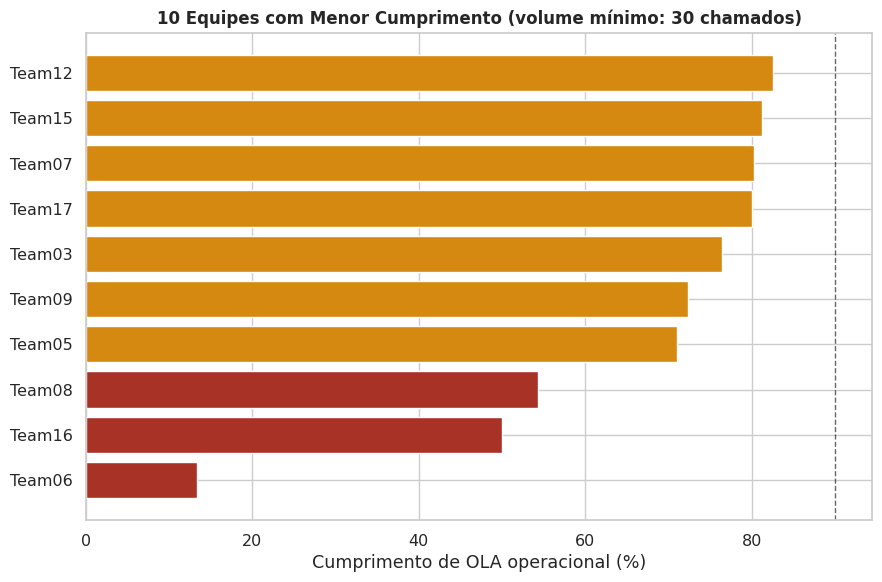

,cumprimento,volume
Grupo designado,,
Team06,13.30,45
Team16,50.00,184
Team08,54.30,116
Team05,71.10,4083
Team09,72.40,2789
Team03,76.50,701
Team17,80.00,650
Team07,80.30,183
Team15,81.20,64


Grupo designado      
Team05           lcem    2558
                 lsin     360
                 lemg     349
Team06           lcem      39
                 lemg       1
                 lrev       1
Team08           lsin      33
                 lsd0      32
                 lhco      20
Team09           lhco    1283
                 lsin     585
                 lrev     250
Team16           lsaa     152
                 lsin      31
                 lmse       1
Name: Produto, dtype: int64

In [ ]:
min_volume = 30

por_equipe = (
    df_ola.groupby('Grupo designado')['ola_status']
    .agg(cumprimento=lambda s: (s == 'Cumprido').mean(), volume='size')
    .query('volume >= @min_volume')
    .sort_values('cumprimento')
)

fig, ax = plt.subplots(figsize=(9, 6))
pior_10 = por_equipe.head(10).sort_values('cumprimento')
cores_barra = ['#a93226' if v < 0.7 else '#d68910' if v < 0.9 else '#1a5276' for v in pior_10['cumprimento']]
ax.barh(pior_10.index, pior_10['cumprimento'] * 100, color=cores_barra)
ax.axvline(90, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Cumprimento de OLA operacional (%)')
ax.set_title(f'10 Equipes com Menor Cumprimento (volume mínimo: {min_volume} chamados)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

display(por_equipe.head(10).assign(cumprimento=lambda d: (d['cumprimento'] * 100).round(1)))

piores_times = por_equipe.head(5).index.tolist()
display(
    df_ola[df_ola['Grupo designado'].isin(piores_times)]
    .groupby('Grupo designado')['Produto']
    .apply(lambda s: s.value_counts().head(3))
)

### Evolução mensal do KPI oficial

O Dicionário de Dados define o KPI como um indicador **medido mensalmente**. A visão agregada acima (99,0%) pode esconder oscilação mês a mês — por isso replicamos o cumprimento do KPI oficial por mês de abertura, sinalizando meses com volume muito baixo (dado ainda incompleto ou pouco representativo).

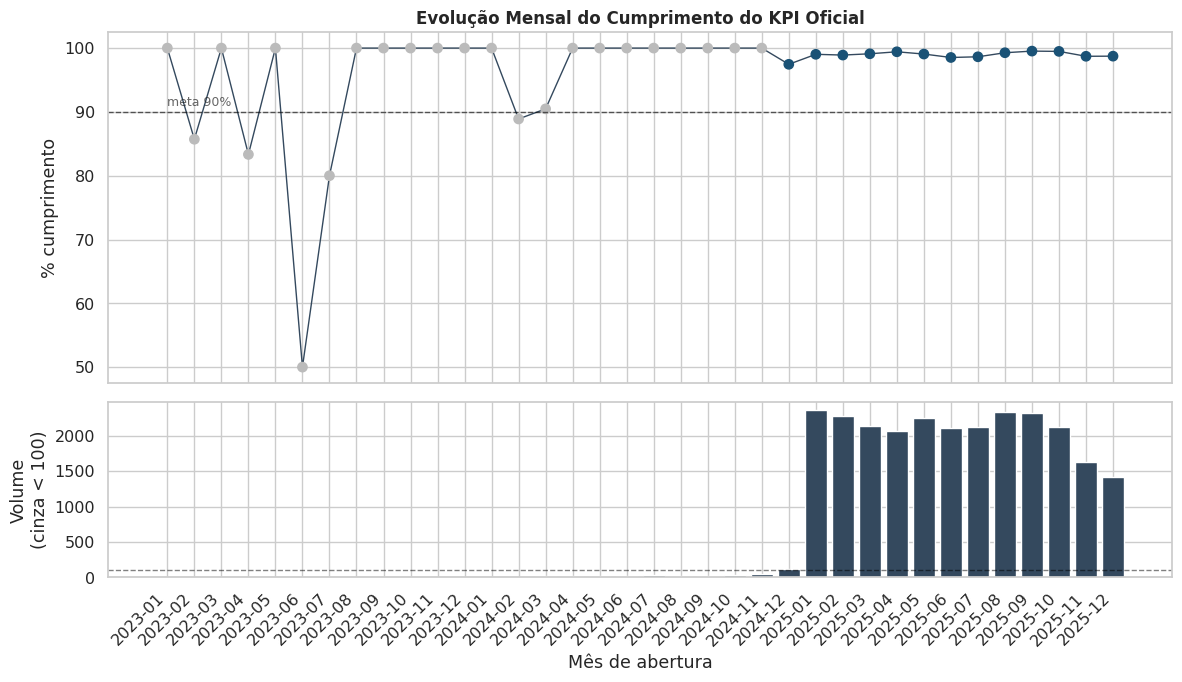

Meses com volume representativo (≥100 incidentes): 13 de 36.
Nesses meses, cumprimento varia entre 97.5% e 99.5% — faixa estreita, sem tendência de piora.
Todos os meses com volume representativo ficam acima da meta de 90%.
Os meses de 2023 e a maior parte de 2024 têm volume muito baixo (a base passa a ter cobertura
consistente do KPI a partir de 2025) — as oscilações nesse período (ex.: 50% em jun/2023) são
artefato de amostra pequena (2 incidentes no mês), não sinal real de queda de desempenho.


In [ ]:
kpi_oficial_mensal = kpi_oficial.copy()
kpi_oficial_mensal['mes_abertura'] = pd.to_datetime(kpi_oficial_mensal['Aberto'], errors='coerce').dt.to_period('M').astype(str)

cumprimento_mensal = (
    kpi_oficial_mensal.groupby('mes_abertura')['KPI Violado?']
    .apply(lambda s: (s == 'NAO').mean() * 100)
    .sort_index()
)
volumetria_mensal = kpi_oficial_mensal.groupby('mes_abertura').size().reindex(cumprimento_mensal.index)

min_volume_mes = 100
mes_confiavel = volumetria_mensal >= min_volume_mes

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

cores_pontos = [paleta_status_ola['Cumprido'] if c else '#bbbbbb' for c in mes_confiavel]
axes[0].plot(cumprimento_mensal.index, cumprimento_mensal.values, color=cor_neutra, linewidth=1, zorder=1)
axes[0].scatter(cumprimento_mensal.index, cumprimento_mensal.values, c=cores_pontos, s=45, zorder=2)
axes[0].axhline(90, color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[0].text(0, 91, 'meta 90%', fontsize=9, alpha=0.7)
axes[0].set_title('Evolução Mensal do Cumprimento do KPI Oficial', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% cumprimento')

axes[1].bar(volumetria_mensal.index, volumetria_mensal.values, color=cor_neutra)
axes[1].axhline(min_volume_mes, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_ylabel(f'Volume\n(cinza < {min_volume_mes})')
axes[1].set_xlabel('Mês de abertura')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

conf = cumprimento_mensal[mes_confiavel]
print(f'Meses com volume representativo (≥{min_volume_mes} incidentes): {mes_confiavel.sum()} de {len(cumprimento_mensal)}.')
print(f'Nesses meses, cumprimento varia entre {conf.min():.1f}% e {conf.max():.1f}% — faixa estreita, sem tendência de piora.')
print(f'Todos os meses com volume representativo ficam acima da meta de 90%.')
print('Os meses de 2023 e a maior parte de 2024 têm volume muito baixo (a base passa a ter cobertura')
print('consistente do KPI a partir de 2025) — as oscilações nesse período (ex.: 50% em jun/2023) são')
print('artefato de amostra pequena (2 incidentes no mês), não sinal real de queda de desempenho.')

### Conclusão

O KPI oficial (restrito a `Entrou para KPI?` = SIM) tem cumprimento de 99,0% — bem acima da meta e que não deve ser confundido com o indicador operacional amplo. Já o OLA operacional, que cobre as 5 prioridades (27,4% da base), tem cumprimento de 84,8%, puxado para baixo pelas prioridades fora da régua contratual (4 e 5).

Comparando o recálculo com o KPI oficial (restrito às prioridades 2 e 3, único universo em que `Entrou para KPI?` = SIM ocorre na base), há 13,3% de divergência; a mediana de estouro nos casos divergentes é de dezenas de vezes o limite, o que descarta erro de borda e aponta para uma diferença estrutural no relógio de SLA. Uma validação cruzada contra a coluna `Diferença_Limite_Duração`, pré-computada de forma independente pelo pipeline Spark, confirma que a fórmula do recálculo está correta — a divergência não é erro de cálculo interno.

A evolução mensal do KPI oficial mostra cumprimento estável, entre 97,5% e 99,5%, em todos os 13 meses com volume representativo (dez/2024 em diante) — sem tendência de piora ao longo do tempo, sempre acima da meta de 90%. Os meses anteriores têm volume baixo demais para leitura confiável. As violações operacionais concentram-se em poucas equipes (Team06, Team16 e Team08, com cumprimento abaixo de 55%). O custo operacional é apresentado como cenário (R$150 a R$500/hora), não como valor financeiro validado; a soma de horas de estouro é sensível a outliers extremos de duração.

Faz sentido reportar o KPI oficial como métrica de risco contratual e usar o OLA operacional só como diagnóstico interno. Vale validar com a área de ITSM a lógica exata do relógio de SLA por trás de `KPI Violado?`, já que a divergência é sistemática, de grande magnitude e não explicada por erro de fórmula. Também vale priorizar investigação qualitativa (Produto/Categoria) nas equipes com menor cumprimento antes de decisões de capacidade, tratar as prioridades 4 e 5 como problema de fila/automação (não de prazo contratual), e validar os valores de R$/hora com a área financeira antes de qualquer uso externo do cenário de custo. O acompanhamento mensal do KPI, como definido no Dicionário de Dados, deveria virar rotina — não só o agregado anual.


## 2. Feature Engineering para Clusterização

`Produto`, `Categoria` e `Subcategoria` são variáveis de alta cardinalidade. One-Hot Encoding gera uma coluna binária por categoria e, em alta cardinalidade, produz um espaço esparso que prejudica algoritmos baseados em distância euclidiana (K-Means). Frequency Encoding substitui cada categoria por sua frequência relativa na base — 1 coluna numérica por variável, preservando o sinal de raridade (proxy de atipicidade) a um custo computacional muito menor.


In [ ]:
colunas_categoricas = ['Produto', 'Categoria', 'Subcategoria']
diagnostico = pd.DataFrame({
    'Cardinalidade': [df[c].nunique() for c in colunas_categoricas],
    '% Preenchido': [(1 - df[c].isna().mean()) * 100 for c in colunas_categoricas],
}, index=colunas_categoricas)
display(diagnostico.round(1))

colunas_ohe_estimadas = sum(df[c].nunique() for c in colunas_categoricas)
print(f'One-Hot Encoding nas 3 colunas geraria +{colunas_ohe_estimadas} colunas binárias esparsas.')
print('Frequency Encoding gera +3 colunas numéricas densas.')

display(df['Produto'].value_counts().head(15).to_frame('Nº incidentes'))

,Cardinalidade,% Preenchido
Produto,51,36.40
Categoria,141,36.60
Subcategoria,447,36.60


One-Hot Encoding nas 3 colunas geraria +639 colunas binárias esparsas.
Frequency Encoding gera +3 colunas numéricas densas.


,Nº incidentes
Produto,
lhco,12835
lsin,7342
lcem,5878
lhvp,4454
lrev,3784
lcho,1368
lcsi,1085
lsaa,919
lrel,905


In [ ]:
df_features = df.copy()
for col in colunas_categoricas:
    freq = df_features[col].value_counts(normalize=True)
    df_features[f'{col.lower()}_freq_enc'] = df_features[col].map(freq).fillna(0)

colunas_freq_enc = [f'{c.lower()}_freq_enc' for c in colunas_categoricas]
display(df_features[[*colunas_categoricas, *colunas_freq_enc]].sample(5, random_state=42))

,Produto,Categoria,Subcategoria,produto_freq_enc,categoria_freq_enc,subcategoria_freq_enc
5884,NaN,NaN,NaN,0.00,0.00,0.00
73043,lrev,cat94,sub95,0.08,0.01,0.02
93371,NaN,NaN,NaN,0.00,0.00,0.00
54674,NaN,NaN,NaN,0.00,0.00,0.00
33951,NaN,NaN,NaN,0.00,0.00,0.00


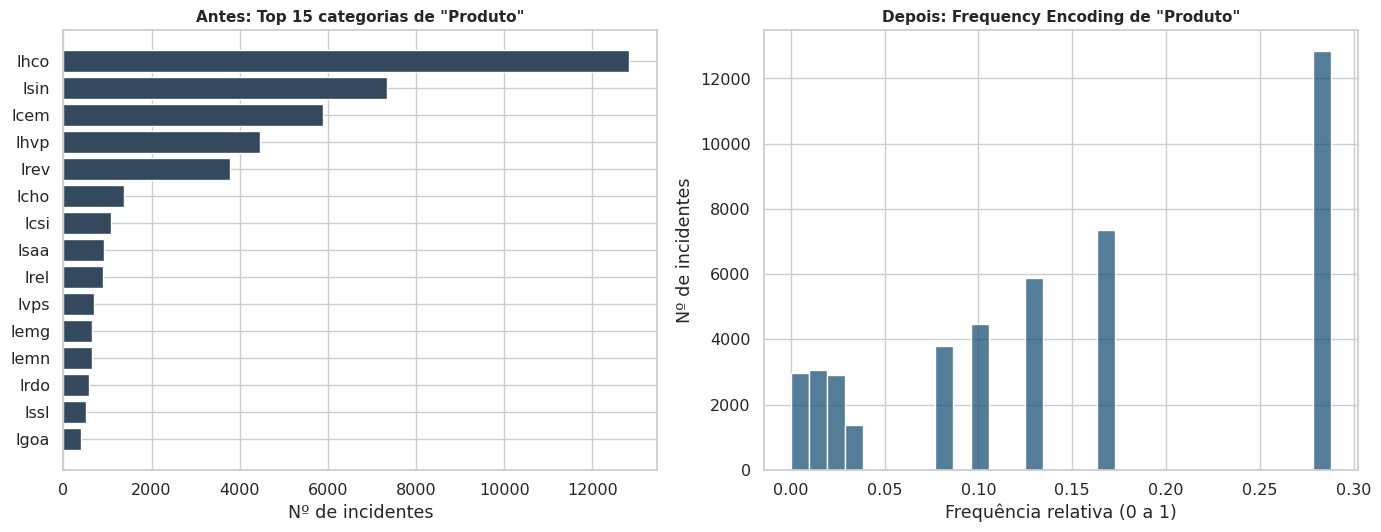

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

top_produtos = df['Produto'].value_counts().head(15)
axes[0].barh(top_produtos.index[::-1], top_produtos.values[::-1], color=cor_neutra)
axes[0].set_title('Antes: Top 15 categorias de "Produto"', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Nº de incidentes')

sns.histplot(df_features['produto_freq_enc'][df_features['produto_freq_enc'] > 0],
             bins=30, ax=axes[1], color='#1a5276')
axes[1].set_title('Depois: Frequency Encoding de "Produto"', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Frequência relativa (0 a 1)')
axes[1].set_ylabel('Nº de incidentes')

plt.tight_layout()
plt.show()

### Tratamento de categorias raras

In [ ]:
limiar_raro = 0.005

freq_subcategoria = df['Subcategoria'].value_counts(normalize=True)
categorias_raras = freq_subcategoria[freq_subcategoria < limiar_raro]
print(f'Subcategorias raras (<{limiar_raro:.1%} de share): {len(categorias_raras)} de {df["Subcategoria"].nunique()} '
      f'({len(categorias_raras) / df["Subcategoria"].nunique():.1%} das categorias, {categorias_raras.sum():.1%} do volume)')

df_features['subcategoria_agrupada'] = df_features['Subcategoria'].where(
    ~df_features['Subcategoria'].isin(categorias_raras.index), 'Outros'
)
print(f'Cardinalidade após agrupamento: {df_features["subcategoria_agrupada"].nunique()} '
      f'(antes: {df["Subcategoria"].nunique()})')

Subcategorias raras (<0.5% de share): 410 de 447 (91.7% das categorias, 21.5% do volume)
Cardinalidade após agrupamento: 38 (antes: 447)


### Conclusão

Produto, Categoria e Subcategoria somam alta cardinalidade (51, 141 e 447 categorias) com preenchimento parcial (~36-37%); One-Hot Encoding geraria +639 colunas binárias esparsas, prejudicando algoritmos de distância como K-Means. Frequency Encoding condensa o sinal em apenas 3 colunas numéricas densas, preservando a informação de raridade como proxy de atipicidade. Das 447 subcategorias, 410 (91,7%) são raras (<0,5% de share, somando 21,5% do volume) e foram agrupadas em "Outros" antes de qualquer etapa de clusterização, reduzindo a cardinalidade de 447 para 38.

Faz sentido adotar Frequency Encoding (ou Target Encoding supervisionado por `KPI Violado?`, quando aplicável) como padrão para variáveis de alta cardinalidade, manter o agrupamento de categorias raras como etapa obrigatória do pipeline (sempre antes da clusterização) e normalizar as features numéricas resultantes (StandardScaler) antes de rodar o K-Means.


## 3. Hierarquia — Incidentes Pais e Filhos

Quando uma causa raiz gera múltiplos incidentes correlacionados, o ITSM registra os subsequentes como filhos de um incidente pai. Sem agrupamento automático, cada filho consome fila, triagem e reporte — ruído operacional que infla métricas de volume sem representar problemas novos.


In [ ]:
tem_pai = df['Incidente Pai'].notna()
filhos = df.loc[tem_pai].copy()
pais_unicos_com_filhos = filhos['Incidente Pai'].nunique()

print(f'Incidentes-filho: {len(filhos):,} ({tem_pai.mean():.1%} da base total)'.replace(',', '.'))
print(f'Incidentes-pai distintos: {pais_unicos_com_filhos:,}'.replace(',', '.'))
print(f'Média de filhos por pai: {len(filhos) / pais_unicos_com_filhos:.1f}')

reducao_potencial = (len(filhos) - pais_unicos_com_filhos) / len(df)
print(f'Redução de volume "efetivo" com agrupamento automático de cascatas: {reducao_potencial:.1%}')

Incidentes-filho: 15.124 (12.3% da base total)
Incidentes-pai distintos: 3.326
Média de filhos por pai: 4.5
Redução de volume "efetivo" com agrupamento automático de cascatas: 9.6%


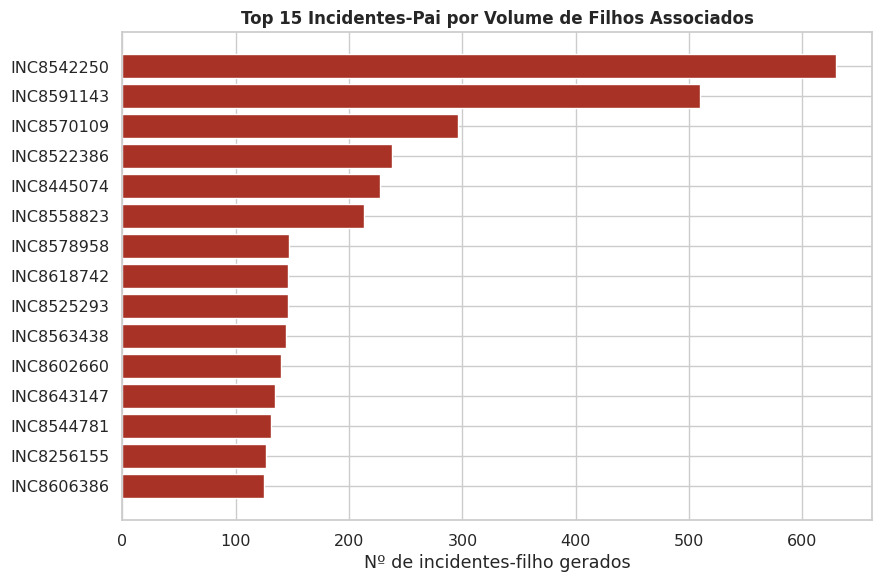

Esses 15 incidentes-pai concentram 3.355 incidentes-filho (22.2% de todos os filhos da base).


,Item de configuração,Produto,Descrição Resumida
77696,IC05317,lsin,"\Problem: Service \""\""Bacula-fd\""\"" (Bacula Fi..."
77727,IC01201,lsin,Problem: Error Backup Inc Bacula
77731,IC00880,lrev,Problem: Error Backup Inc Bacula
77732,IC01486,lrev,Problem: Error Backup Inc Bacula
77733,IC02112,lrev,Problem: Error Backup Inc Bacula
77734,IC01767,lrev,Problem: Error Backup Inc Bacula
77737,IC05317,lsin,Problem: Error Backup Full Bacula
77739,IC05321,lhco,Problem: Error Backup Full Bacula
77740,IC05322,NaN,Problem: Error Backup Inc Bacula
77748,IC03185,NaN,Problem: Error Backup Inc Bacula


In [ ]:
top_pais = filhos['Incidente Pai'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_pais.index[::-1], top_pais.values[::-1], color='#a93226')
ax.set_title('Top 15 Incidentes-Pai por Volume de Filhos Associados', fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de incidentes-filho gerados')
plt.tight_layout()
plt.show()

print(f'Esses 15 incidentes-pai concentram {top_pais.sum():,} incidentes-filho '
      f'({top_pais.sum() / len(filhos):.1%} de todos os filhos da base).'.replace(',', '.'))

maior_pai = top_pais.index[0]
display(filhos.loc[filhos['Incidente Pai'] == maior_pai, ['Item de configuração', 'Produto', 'Descrição Resumida']].drop_duplicates().head(10))

### Distribuição do tamanho das cascatas

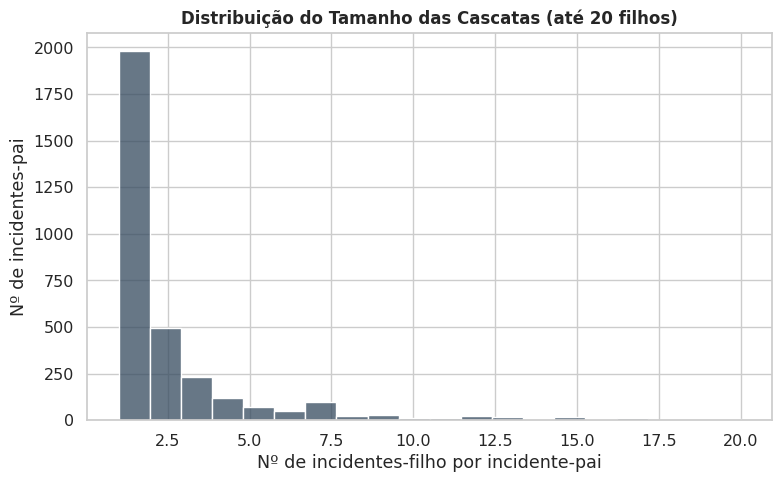

count   3,326.00
mean        4.55
std        19.70
min         1.00
25%         1.00
50%         1.00
75%         3.00
max       630.00
Name: count, dtype: float64

% de pais com apenas 1 filho: 59.5%
% de pais com 10+ filhos (tempestade relevante): 6.9%


In [ ]:
distribuicao_cascata = filhos['Incidente Pai'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(distribuicao_cascata[distribuicao_cascata <= 20], bins=20, color=cor_neutra, ax=ax)
ax.set_title('Distribuição do Tamanho das Cascatas (até 20 filhos)', fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de incidentes-filho por incidente-pai')
ax.set_ylabel('Nº de incidentes-pai')
plt.tight_layout()
plt.show()

print(distribuicao_cascata.describe())
print(f'\n% de pais com apenas 1 filho: {(distribuicao_cascata == 1).mean():.1%}')
print(f'% de pais com 10+ filhos (tempestade relevante): {(distribuicao_cascata >= 10).mean():.1%}')

### Cruzamento com o cumprimento de OLA e o tipo de solução

Duas perguntas que conectam as análises: incidentes-filho de cascatas grandes cumprem prazo pior do que os de cascatas pequenas? E incidentes fechados com Contorno têm mais chance de, no futuro, se tornarem "pai" de uma nova cascata? (Cálculo diagnóstico — segue a mesma régua de duração/limite do OLA operacional, fora da métrica oficial de KPI.)


In [ ]:
# 3a) OLA operacional (diagnóstico) dos incidentes-filho, por tamanho da cascata do pai
tam_cascata = filhos['Incidente Pai'].value_counts()
filhos_diag = filhos.copy()
filhos_diag['tamanho_cascata'] = filhos_diag['Incidente Pai'].map(tam_cascata)
filhos_diag['cascata_grande'] = filhos_diag['tamanho_cascata'] >= 10
filhos_diag = filhos_diag[filhos_diag['Status'] != 'Sem Intervenção'].copy()
filhos_diag['limite_ola_s'] = filhos_diag['Prioridade'].map(limites_ola_segundos)
filhos_diag['ola_status'] = np.where(filhos_diag['Duração'] <= filhos_diag['limite_ola_s'], 'Cumprido', 'Violado')

cumprimento_por_cascata = (
    filhos_diag.groupby('cascata_grande')['ola_status']
    .apply(lambda s: (s == 'Cumprido').mean() * 100)
    .rename({True: 'Cascata grande (10+ filhos)', False: 'Cascata pequena (<10 filhos)'})
)
display(cumprimento_por_cascata.round(1).to_frame('% Cumprido (diagnóstico)'))

# 3b) % de incidentes que, depois de resolvidos, viram "pai" de algum incidente futuro
pais_set = set(df['Incidente Pai'].dropna().unique())
apenas_informado_pai = df[df['Solução'].notna()].copy()
apenas_informado_pai['virou_pai'] = apenas_informado_pai['Número'].isin(pais_set)
taxa_virou_pai = apenas_informado_pai.groupby('Solução')['virou_pai'].mean().mul(100)
display(taxa_virou_pai.round(1).to_frame('% que virou "pai" de cascata'))

print(f'Filhos de cascata grande cumprem OLA operacional em {cumprimento_por_cascata["Cascata grande (10+ filhos)"]:.1f}% dos casos, '
      f'contra {cumprimento_por_cascata["Cascata pequena (<10 filhos)"]:.1f}% nas cascatas pequenas — o oposto do que se poderia supor: '
      f'cascatas grandes tendem a ser resolvidas em bloco (mesma causa raiz), enquanto filhos isolados são tratados individualmente e demoram mais.')
print(f'Incidentes fechados com Contorno viram "pai" de cascata futura em {taxa_virou_pai["Contorno"]:.1f}% dos casos, '
      f'contra {taxa_virou_pai["Definitiva"]:.1f}% para Definitiva — mais um sinal (junto com a reincidência do Pilar 4) '
      f'de que o Contorno deixa a causa raiz ativa.')

,% Cumprido (diagnóstico)
cascata_grande,
Cascata pequena (<10 filhos),80.30
Cascata grande (10+ filhos),91.00


,"% que virou ""pai"" de cascata"
Solução,
Contorno,10.30
Definitiva,7.10


Filhos de cascata grande cumprem OLA operacional em 91.0% dos casos, contra 80.3% nas cascatas pequenas — o oposto do que se poderia supor: cascatas grandes tendem a ser resolvidas em bloco (mesma causa raiz), enquanto filhos isolados são tratados individualmente e demoram mais.
Incidentes fechados com Contorno viram "pai" de cascata futura em 10.3% dos casos, contra 7.1% para Definitiva — mais um sinal (junto com a reincidência do Pilar 4) de que o Contorno deixa a causa raiz ativa.


### Conclusão

15.124 incidentes (12,3% da base completa, as duas partições) são filhos de 3.326 incidentes-pai distintos — média de 4,5 filhos por pai. A distribuição é assimétrica: 59,5% dos pais têm só 1 filho, mas 6,9% têm 10 ou mais filhos, configurando cascatas de grande impacto (o maior caso chega a 630 filhos). Os 15 maiores incidentes-pai concentram 22,2% de todos os incidentes-filho da base, coerente com eventos de infraestrutura compartilhada (ex.: falhas recorrentes de backup).

Contra-intuitivamente, incidentes-filho de cascatas grandes (10+ filhos) cumprem o prazo operacional melhor do que os de cascatas pequenas — cascatas grandes tendem a ser resolvidas em bloco assim que a causa raiz é tratada, enquanto filhos isolados são tratados um a um e acumulam atraso. Incidentes fechados com Contorno também têm mais chance de, no futuro, aparecer como "pai" de uma nova cascata do que os fechados com Definitiva — reforça, por outro ângulo, o achado da seção 4 de que o Contorno deixa a causa raiz ativa.

Vale implementar detecção automática de correlação (Item de Configuração + janela de tempo) para agrupar incidentes futuros em tempo real, priorizar fluxo de major incident para cascatas com 10+ filhos (liberando capacidade do time para tratar a causa raiz) e usar o histórico de "virou pai" como critério extra, além da reincidência, para decidir quando escalonar um Contorno para solução definitiva. Cascatas pequenas (1-2 filhos) podem seguir processo padrão — não justificam automação especial, mas merecem atenção pelo cumprimento de prazo pior.


## 4. Tipo de Solução — Contorno vs. Definitiva

O campo `Solução` indica se o incidente foi encerrado com correção definitiva (elimina a causa raiz) ou contorno (mitiga o sintoma, mantendo a causa raiz ativa). Hipótese de negócio: contornos aceleram o fechamento no curto prazo às custas de reincidência futura — dívida técnica.


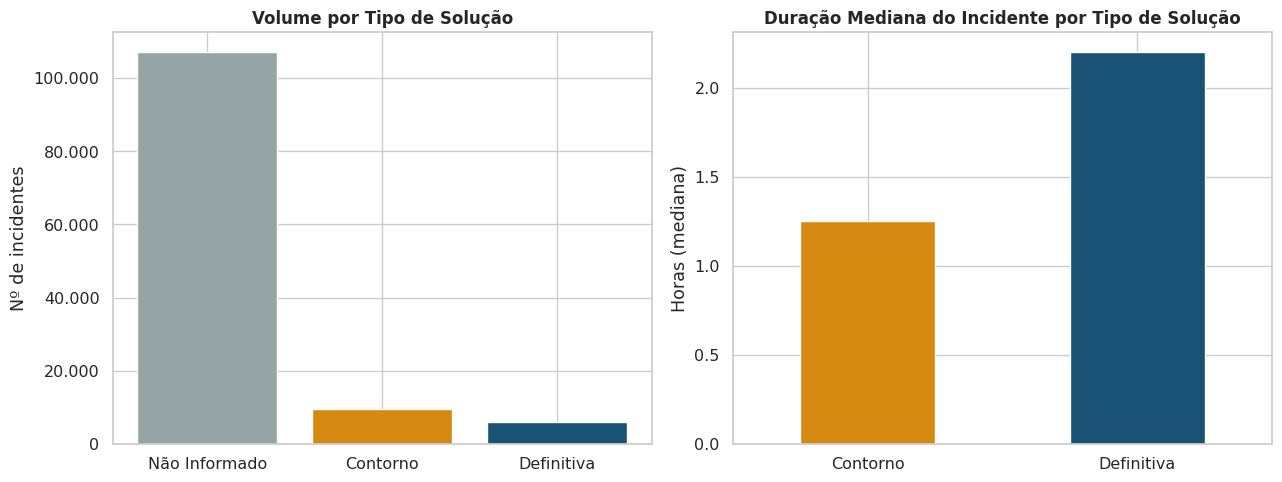

In [ ]:
df['solucao_tratada'] = df['Solução'].fillna('Não Informado')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

contagem_solucao = df['solucao_tratada'].value_counts()
axes[0].bar(contagem_solucao.index, contagem_solucao.values,
            color=[paleta_solucao.get(c, cor_neutra) for c in contagem_solucao.index])
axes[0].set_title('Volume por Tipo de Solução', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nº de incidentes')
formata_milhar(axes[0], eixo='y')

apenas_informado = df[df['Solução'].notna()]
mediana_duracao_h = (apenas_informado.groupby('Solução')['Duração'].median() / 3600)
mediana_duracao_h.plot(kind='bar', ax=axes[1],
                        color=[paleta_solucao[c] for c in mediana_duracao_h.index])
axes[1].set_title('Duração Mediana do Incidente por Tipo de Solução', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Horas (mediana)')
axes[1].set_xlabel('')
plt.setp(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
nao_informado = df[df['Solução'].isna()]
display(nao_informado['Status'].value_counts().to_frame('Nº incidentes'))
display(nao_informado['Aberto por'].value_counts().to_frame('Nº incidentes'))
print('A maioria dos registros sem Solução tem Status = "Sem Intervenção" e Aberto por = "Monitoramento":')
print('chamados abertos automaticamente e fechados sem intervenção humana, portanto sem classificação de solução.')

,Nº incidentes
Status,
Sem Intervenção,80373
Encerrado Automaticamente,16605
Encerrado,10264
Aguardando Problema,1


,Nº incidentes
Aberto por,
Monitoramento,95462
Manual,11781


A maioria dos registros sem Solução tem Status = "Sem Intervenção" e Aberto por = "Monitoramento":
chamados abertos automaticamente e fechados sem intervenção humana, portanto sem classificação de solução.


In [ ]:
mediana_contorno = apenas_informado.loc[apenas_informado['Solução'] == 'Contorno', 'Duração'].median() / 3600
mediana_definitiva = apenas_informado.loc[apenas_informado['Solução'] == 'Definitiva', 'Duração'].median() / 3600
print(f'Duração mediana — Contorno: {mediana_contorno:.1f}h | Definitiva: {mediana_definitiva:.1f}h')
print(f'Contorno fecha, tipicamente, {(1 - mediana_contorno / mediana_definitiva):.0%} mais rápido que uma solução definitiva.')

Duração mediana — Contorno: 1.3h | Definitiva: 2.2h
Contorno fecha, tipicamente, 43% mais rápido que uma solução definitiva.


In [ ]:
df['aberto_dt'] = pd.to_datetime(df['Aberto'], errors='coerce')

historico_ic = (
    df.dropna(subset=['Item de configuração', 'aberto_dt'])
    .sort_values(['Item de configuração', 'aberto_dt'])
    .copy()
)
historico_ic['proxima_abertura'] = historico_ic.groupby('Item de configuração')['aberto_dt'].shift(-1)
historico_ic['horas_ate_reincidencia'] = (
    (historico_ic['proxima_abertura'] - historico_ic['aberto_dt']).dt.total_seconds() / 3600
)

comparativo = historico_ic[historico_ic['Solução'].isin(['Contorno', 'Definitiva'])].dropna(
    subset=['horas_ate_reincidencia']
)

janelas = [24, 72, 168]
reincidencia_por_janela = pd.DataFrame({
    f'≤ {h}h': comparativo.groupby('Solução')['horas_ate_reincidencia'].apply(lambda s, h=h: (s <= h).mean())
    for h in janelas
}).mul(100)

display(reincidencia_por_janela.round(1))

,≤ 24h,≤ 72h,≤ 168h
Solução,,,
Contorno,58.00,73.80,85.30
Definitiva,54.30,65.00,76.00


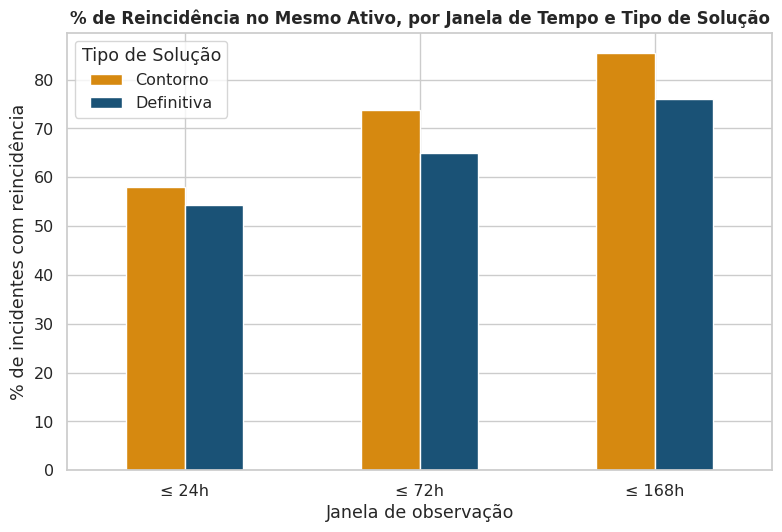

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
reincidencia_por_janela.T.plot(kind='bar', ax=ax,
                                 color=[paleta_solucao['Contorno'], paleta_solucao['Definitiva']])
ax.set_title('% de Reincidência no Mesmo Ativo, por Janela de Tempo e Tipo de Solução',
             fontsize=12, fontweight='bold')
ax.set_ylabel('% de incidentes com reincidência')
ax.set_xlabel('Janela de observação')
plt.setp(ax.get_xticklabels(), rotation=0)
ax.legend(title='Tipo de Solução')
plt.tight_layout()
plt.show()

### A diferença de reincidência é estatisticamente significativa?

Com milhares de casos, mesmo diferenças pequenas em % podem "parecer" reais sem ser. Testamos formalmente, para cada janela, se a proporção de reincidência de Contorno é estatisticamente diferente da de Definitiva (teste qui-quadrado de independência).

In [ ]:
from scipy import stats

resultados_teste = []
for h in janelas:
    reincidiu_h = comparativo['horas_ate_reincidencia'] <= h
    tabela_h = pd.crosstab(comparativo['Solução'], reincidiu_h)
    chi2, p_valor, _, _ = stats.chi2_contingency(tabela_h)
    resultados_teste.append({'Janela': f'≤ {h}h', 'chi2': round(chi2, 1), 'p-valor': f'{p_valor:.2e}',
                              'Significativo (p<0,05)': 'Sim' if p_valor < 0.05 else 'Não'})

display(pd.DataFrame(resultados_teste).set_index('Janela'))
print('Em todas as janelas, p-valor << 0,05: a diferença de reincidência entre Contorno e Definitiva')
print('não é explicada por acaso amostral — é um efeito real e consistente, com alta confiança estatística.')

,chi2,p-valor,"Significativo (p<0,05)"
Janela,,,
≤ 24h,16.70,4.44e-05,Sim
≤ 72h,111.30,5.12e-26,Sim
≤ 168h,178.40,1.08e-40,Sim


Em todas as janelas, p-valor << 0,05: a diferença de reincidência entre Contorno e Definitiva
não é explicada por acaso amostral — é um efeito real e consistente, com alta confiança estatística.


### Conclusão

Contorno tem duração mediana de 1,3h contra 2,2h da solução Definitiva — fecha cerca de 43% mais rápido. A reincidência do mesmo Item de Configuração é maior após Contorno em todas as janelas observadas: 58,0% vs. 54,3% em 24h, 73,8% vs. 65,0% em 72h e 85,3% vs. 76,0% em 168h. Um teste qui-quadrado confirma que essa diferença é estatisticamente significativa nas três janelas (p-valor muito abaixo de 0,05) — não é ruído de amostra.

A análise usa somente os 15.300 incidentes (12,5% da base) com campo Solução preenchido; os demais ("Não Informado") são majoritariamente chamados com Status = "Sem Intervenção" e Aberto por = "Monitoramento" — fechados sem intervenção humana, não um problema de dado faltando.

Vale instituir um gatilho de governança: Item de Configuração com 2+ contornos em uma janela definida (ex.: 30 dias) deve ser escalonado para tratamento de causa raiz. A métrica executiva de "% OLA cumprido" poderia evoluir para "% OLA cumprido com solução definitiva". "Não Informado" não deve ser tratado como dado faltando ao reportar Contorno vs. Definitiva — excluí-lo da análise de tipo de solução é o procedimento correto. A significância estatística confirmada é um bom argumento para priorizar o gatilho de governança junto à liderança, já que o efeito é real, não uma impressão dos dados.


## Síntese Final

O KPI oficial está acima de 99%, e o OLA operacional amplo reflete fila — não risco contratual; vale separar as duas métricas em relatórios e validar o relógio de SLA com o ITSM. A alta cardinalidade de Produto/Categoria/Subcategoria é tratável via Frequency Encoding e agrupamento das categorias raras, o que deve virar padrão do pipeline antes da clusterização. Poucos incidentes-pai concentram a maior parte do ruído de volume, o que justifica agrupamento automático de cascatas grandes via major incident. E o Contorno é mais rápido no curto prazo, mas eleva a reincidência — o que pede governança de escalonamento para solução definitiva.


## Exportação dos Datasets de Machine Learning

Esta seção reaproveita os DataFrames e as features já construídos ao longo das quatro análises acima (`df`, `df_features`, `df_ola`, `filhos`, `filhos_diag`, `historico_ic`, `pais_set`, entre outros) para consolidar, validar e exportar três arquivos:

| Arquivo | Conteúdo |
|---|---|
| `features_master.csv` | Dataset mestre completo — todas as features originais e derivadas, sem remoções por risco de Data Leakage |
| `features_modelagem.csv` | Subconjunto seguro para modelagem preditiva — exclui colunas com alto risco de vazamento (informação só disponível após o incidente ser resolvido/encerrado) |
| `feature_metadata.csv` | Dicionário de dados de cada feature (origem, disponibilidade temporal, risco de leakage, potencial de target) |


### Preparação final das features

In [ ]:

# Reaproveita df, df_features, df_ola, filhos, filhos_diag, pais_set, historico_ic, etc.,
# já construídos nas seções acima. Nenhuma célula anterior é recalculada do zero.

features = df_features.copy()  # já contém produto/categoria/subcategoria_freq_enc + subcategoria_agrupada

# df_features foi criado (cópia de df) ANTES de 'solucao_tratada' (Pilar 4) e 'aberto_dt' (Pilar 4)
# terem sido adicionadas a df. Reaproveitamos essas duas colunas de df via merge por 'Número'.
features = features.merge(
    df[['Número', 'solucao_tratada', 'aberto_dt']], on='Número', how='left'
)

# --- Features de OLA/SLA (Pilar 1) — broadcast a partir de df_ola para toda a base ---
features['elegivel_ola_operacional'] = features['Número'].isin(df_ola['Número'])
features['limite_ola_s'] = features['Prioridade'].map(limites_ola_segundos)

ola_status_map = df_ola.set_index('Número')['ola_status']
features['ola_status'] = features['Número'].map(ola_status_map)
features['ola_cumprido_bin'] = features['ola_status'].map({'Cumprido': 1, 'Violado': 0})
features['diferenca_duracao_limite_s'] = features['Duração'] - features['limite_ola_s']

violados_map = df_ola.loc[df_ola['ola_status'] == 'Violado'].set_index('Número')
features['horas_estouro'] = features['Número'].map(
    (violados_map['Duração'] - violados_map['limite_ola_s']) / 3600
)

# --- Features de KPI (Pilar 1) ---
features['kpi_entrou_bin'] = (features['Entrou para KPI?'] == 'SIM').astype(int)
features['kpi_violado_bin'] = np.where(
    features['Entrou para KPI?'] == 'SIM',
    (features['KPI Violado?'] == 'SIM').astype(int),
    np.nan,
)

# --- Hierarquia Pai/Filho (Pilar 3) ---
features['tem_incidente_pai'] = features['Incidente Pai'].notna()
features['eh_incidente_pai'] = features['Número'].isin(pais_set)

tam_cascata_map = filhos['Incidente Pai'].value_counts()
features['quantidade_filhos'] = features['Número'].map(tam_cascata_map).fillna(0).astype(int)
features['tamanho_cascata_do_pai'] = features['Incidente Pai'].map(tam_cascata_map)
features['cascata_grande'] = features['tamanho_cascata_do_pai'] >= 10

virou_pai_map = apenas_informado_pai.set_index('Número')['virou_pai']
features['virou_pai_futuramente'] = features['Número'].map(virou_pai_map)

# --- Reincidência (Pilar 4) — a partir de historico_ic (já ordenado por Item de configuração + aberto_dt) ---
reinc_cols = historico_ic.set_index('Número')[['proxima_abertura', 'horas_ate_reincidencia']]
features = features.merge(reinc_cols, on='Número', how='left')
for h in janelas:
    features[f'reincidencia_{h}h'] = np.where(
        features['horas_ate_reincidencia'].notna(),
        (features['horas_ate_reincidencia'] <= h),
        np.nan,
    )

# Contagem de ocorrências ANTERIORES no mesmo Item de configuração — olha só para o passado,
# por isso não é Data Leakage (diferente de horas_ate_reincidencia/reincidencia_*h, que olham o futuro).
hist_sorted = (
    df.dropna(subset=['Item de configuração', 'aberto_dt'])
    .sort_values(['Item de configuração', 'aberto_dt'])
    .copy()
)
hist_sorted['qtd_ocorrencias_anteriores_mesmo_ic'] = hist_sorted.groupby('Item de configuração').cumcount()
qtd_map = hist_sorted.set_index('Número')['qtd_ocorrencias_anteriores_mesmo_ic']
features['qtd_ocorrencias_anteriores_mesmo_ic'] = features['Número'].map(qtd_map)
features['indicador_reincidente_historico'] = features['qtd_ocorrencias_anteriores_mesmo_ic'] > 0

# --- Features temporais (a partir de aberto_dt, já criado no Pilar 4) ---
features['ano_abertura'] = features['aberto_dt'].dt.year
features['mes_abertura'] = features['aberto_dt'].dt.month
features['dia_abertura'] = features['aberto_dt'].dt.day
features['dia_semana_abertura'] = features['aberto_dt'].dt.dayofweek  # 0 = segunda-feira
features['hora_abertura'] = features['aberto_dt'].dt.hour
features['mes_ano_abertura'] = features['aberto_dt'].dt.to_period('M').astype(str)
features['fim_de_semana'] = features['dia_semana_abertura'].isin([5, 6])
features['horario_comercial'] = (
    (~features['fim_de_semana'])
    & (features['hora_abertura'] >= 9)
    & (features['hora_abertura'] < 18)
)

print(f'Features consolidadas: {features.shape[0]:,} linhas x {features.shape[1]} colunas'.replace(',', '.'))


Features consolidadas: 122.543 linhas x 58 colunas


### Validação das features

In [ ]:

print(f'Linhas: {features.shape[0]:,}'.replace(',', '.'))
print(f'Colunas: {features.shape[1]}')
print(f'\nDuplicatas em "Número" (deveria ser 0, é a chave única do incidente): {features["Número"].duplicated().sum()}')

print('\nTipos de dado por coluna:')
display(features.dtypes.value_counts().to_frame('Nº de colunas'))

nulos_pct = features.isna().mean().mul(100).round(1).sort_values(ascending=False)
print('\nColunas com maior % de nulos (esperado para features pós-encerramento, elegibilidade condicional, etc.):')
display(nulos_pct[nulos_pct > 0].head(15).to_frame('% Nulo'))

print(f'\nNomes das colunas ({features.shape[1]}):')
print(list(features.columns))

problemas = []
if features['Número'].duplicated().any():
    problemas.append('Existem duplicatas em "Número".')
if features.shape[0] != len(df):
    problemas.append('Número de linhas de "features" difere de "df" original.')

if problemas:
    print('\n⚠️ Problemas encontrados:')
    for p in problemas:
        print(f'  - {p}')
else:
    print('\n✅ Nenhum problema estrutural encontrado (sem duplicatas, mesmo nº de linhas do df original).')


Linhas: 122.543
Colunas: 58

Duplicatas em "Número" (deveria ser 0, é a chave única do incidente): 0

Tipos de dado por coluna:


,Nº de colunas
object,22
float64,13
bool,10
int64,6
int32,5
"datetime64[ns, UTC]",2



Colunas com maior % de nulos (esperado para features pós-encerramento, elegibilidade condicional, etc.):


,% Nulo
horas_estouro,95.80
Incidente Pai,87.70
tamanho_cascata_do_pai,87.70
virou_pai_futuramente,87.50
Solução,87.50
KPI Violado?,79.10
kpi_violado_bin,79.10
ola_status,72.60
ola_cumprido_bin,72.60
Tempo_Pos_Resolução,67.20



Nomes das colunas (58):
['Número', 'Prioridade', 'Produto', 'Categoria', 'Subcategoria', 'Grupo designado', 'Item de configuração', 'Aberto', 'Resolvido', 'Encerrado', 'Duração', 'Descrição Resumida', 'Solução', 'Aberto por', 'Incidente Pai', 'Status', 'Entrou para KPI?', 'KPI Violado?', 'Tempo_Pos_Resolução', 'Resolvido_after_Encerrado', 'Duração_is_inconsistent', 'Diferença_Limite_Duração', 'Modified_Record', 'produto_freq_enc', 'categoria_freq_enc', 'subcategoria_freq_enc', 'subcategoria_agrupada', 'solucao_tratada', 'aberto_dt', 'elegivel_ola_operacional', 'limite_ola_s', 'ola_status', 'ola_cumprido_bin', 'diferenca_duracao_limite_s', 'horas_estouro', 'kpi_entrou_bin', 'kpi_violado_bin', 'tem_incidente_pai', 'eh_incidente_pai', 'quantidade_filhos', 'tamanho_cascata_do_pai', 'cascata_grande', 'virou_pai_futuramente', 'proxima_abertura', 'horas_ate_reincidencia', 'reincidencia_24h', 'reincidencia_72h', 'reincidencia_168h', 'qtd_ocorrencias_anteriores_mesmo_ic', 'indicador_reincident

### Identificação de Data Leakage e construção do dicionário de dados

Para cada feature, documentamos: tipo de dado, origem, descrição, categoria, disponibilidade temporal, se pode ser usada como feature de entrada, se é um target em potencial, o risco de Data Leakage e uma observação. A classificação de "disponibilidade" segue o momento em que a informação passa a existir:

 - inicio_incidente: conhecida na abertura do chamado (segura para features de entrada)
 - durante_atendimento: passa a existir enquanto o incidente ainda está em curso
 - apos_encerramento: só existe depois que o incidente é resolvido/encerrado (risco de leakage)
 - target: candidata a variável-alvo de um modelo futuro


In [ ]:

META = {}

def meta(nome, tipo, origem, desc, cat, disp, pode_feat, target_pot, risco_leak, obs=''):
    META[nome] = dict(
        feature=nome, tipo_dado=tipo, origem=origem, descricao=desc, categoria=cat,
        disponibilidade=disp, pode_ser_feature=pode_feat, target_potencial=target_pot,
        risco_data_leakage=risco_leak, observacao=obs,
    )

# Colunas originais do dataset (b_incidentes.csv)
meta('Número', 'string', 'original', 'Identificador único do incidente', 'identificador',
     'inicio_incidente', False, False, 'nao', 'Chave primária; não é feature de entrada.')
meta('Prioridade', 'categórica', 'original', 'Prioridade atribuída ao incidente', 'categorica',
     'inicio_incidente', True, False, 'nao', 'Definida na abertura; usada para calcular limite_ola_s.')
meta('Produto', 'categórica (alta cardinalidade)', 'original', 'Produto associado ao incidente', 'categorica',
     'inicio_incidente', True, False, 'nao', 'Ver produto_freq_enc (Pilar 2) para uso em modelos de distância.')
meta('Categoria', 'categórica (alta cardinalidade)', 'original', 'Categoria do incidente', 'categorica',
     'inicio_incidente', True, False, 'nao', 'Ver categoria_freq_enc (Pilar 2).')
meta('Subcategoria', 'categórica (alta cardinalidade)', 'original', 'Subcategoria do incidente', 'categorica',
     'inicio_incidente', True, False, 'nao', 'Ver subcategoria_freq_enc / subcategoria_agrupada (Pilar 2).')
meta('Grupo designado', 'categórica', 'original', 'Equipe responsável pelo atendimento', 'categorica',
     'inicio_incidente', True, False, 'baixo', 'Assumido como definido próximo à abertura (roteamento); validar com a área de ITSM.')
meta('Item de configuração', 'categórica (alta cardinalidade)', 'original', 'Ativo/CI relacionado ao incidente', 'categorica',
     'inicio_incidente', True, False, 'nao', 'Base para as features de reincidência (Pilar 4).')
meta('Aberto', 'datetime (string)', 'original', 'Timestamp de abertura do incidente', 'temporal',
     'inicio_incidente', True, False, 'nao', 'Ver aberto_dt (parseado) e as features temporais derivadas.')
meta('Resolvido', 'datetime (string)', 'original', 'Timestamp de resolução do incidente', 'temporal',
     'apos_encerramento', False, False, 'alto', 'Só existe após o incidente ser resolvido.')
meta('Encerrado', 'datetime (string)', 'original', 'Timestamp de encerramento do incidente', 'temporal',
     'apos_encerramento', False, False, 'alto', 'Só existe após o incidente ser encerrado.')
meta('Duração', 'numérica (segundos)', 'original', 'Duração total do incidente', 'metrica',
     'apos_encerramento', False, False, 'alto', 'Calculada a partir de Aberto/Resolvido/Encerrado; só conhecida ao final.')
meta('Descrição Resumida', 'texto livre', 'original', 'Descrição textual do incidente', 'texto',
     'inicio_incidente', True, False, 'baixo', 'Disponível na abertura; exigiria NLP para virar feature numérica.')
meta('Solução', 'categórica', 'original', 'Tipo de solução aplicada (Contorno/Definitiva)', 'categorica',
     'apos_encerramento', False, True, 'alto', 'Só é conhecida no encerramento (Pilar 4); ver solucao_tratada.')
meta('Aberto por', 'categórica', 'original', 'Origem/autor da abertura do incidente', 'categorica',
     'inicio_incidente', True, False, 'nao', '')
meta('Incidente Pai', 'string (id)', 'original', 'Número do incidente-pai, se houver', 'hierarquia',
     'inicio_incidente', True, False, 'nao', 'Preenchido já na abertura, quando aplicável; ver tem_incidente_pai.')
meta('Status', 'categórica', 'original', 'Status atual/final do incidente', 'categorica',
     'apos_encerramento', False, False, 'medio', 'Reflete o status no momento da extração; pode mudar em incidentes ainda abertos.')
meta('Entrou para KPI?', 'categórica (SIM/NAO)', 'original', 'Indica se o incidente entra no KPI oficial', 'kpi',
     'inicio_incidente', True, False, 'baixo', 'Regra de negócio baseada apenas na Prioridade (1, 2 ou 3); ver kpi_entrou_bin.')
meta('KPI Violado?', 'categórica (SIM/NAO/N-A)', 'original', 'Indica se o KPI oficial foi violado', 'kpi',
     'apos_encerramento', False, True, 'alto', 'Só é conhecida após a resolução/encerramento (Pilar 1); ver kpi_violado_bin.')
meta('Tempo_Pos_Resolução', 'numérica', 'original', 'Tempo entre resolução e encerramento (pré-computado, pipeline Spark)', 'metrica',
     'apos_encerramento', False, False, 'alto', 'Depende de Resolvido/Encerrado.')
meta('Resolvido_after_Encerrado', 'booleana', 'original', 'Flag de inconsistência: Resolvido após Encerrado', 'qualidade_dado',
     'apos_encerramento', False, False, 'alto', 'Só pode ser calculada depois que os dois timestamps existem.')
meta('Duração_is_inconsistent', 'booleana', 'original', 'Flag de inconsistência da Duração', 'qualidade_dado',
     'apos_encerramento', False, False, 'alto', 'Depende da Duração final.')
meta('Diferença_Limite_Duração', 'numérica', 'original', 'Diferença pré-computada (Spark) entre Duração e limite de OLA', 'metrica',
     'apos_encerramento', False, False, 'alto', 'Usada no notebook (Pilar 1) só para validação cruzada da fórmula de OLA.')
meta('Modified_Record', 'booleana', 'original', 'Flag de registro modificado pelo pipeline', 'qualidade_dado',
     'apos_encerramento', False, False, 'medio', 'Metadado de pipeline, não uma característica do incidente em si.')

# Features derivadas — Pilar 2 (Feature Engineering / cardinalidade)
meta('produto_freq_enc', 'numérica (0-1)', 'derivada (Pilar 2)', 'Frequency Encoding de Produto', 'engenharia_features',
     'inicio_incidente', True, False, 'nao', 'Calculado sobre toda a base (ver nota de cardinalidade no notebook).')
meta('categoria_freq_enc', 'numérica (0-1)', 'derivada (Pilar 2)', 'Frequency Encoding de Categoria', 'engenharia_features',
     'inicio_incidente', True, False, 'nao', '')
meta('subcategoria_freq_enc', 'numérica (0-1)', 'derivada (Pilar 2)', 'Frequency Encoding de Subcategoria', 'engenharia_features',
     'inicio_incidente', True, False, 'nao', '')
meta('subcategoria_agrupada', 'categórica', 'derivada (Pilar 2)', 'Subcategoria com categorias raras agrupadas em "Outros"', 'engenharia_features',
     'inicio_incidente', True, False, 'nao', f'Limiar de raridade usado no notebook: {limiar_raro:.1%} de share.')

# Features derivadas — Pilar 4 (solução / temporal)
meta('solucao_tratada', 'categórica', 'derivada (Pilar 4)', 'Solução com nulos preenchidos como "Não Informado"', 'categorica',
     'apos_encerramento', False, True, 'alto', 'Mesma disponibilidade de Solução: só existe no encerramento.')
meta('aberto_dt', 'datetime', 'derivada (Pilar 4)', 'Timestamp de abertura parseado (datetime)', 'temporal',
     'inicio_incidente', True, False, 'nao', 'Base para todas as features temporais.')

# Features derivadas — Pilar 1 (OLA/KPI)
meta('elegivel_ola_operacional', 'booleana', 'derivada (Pilar 1)', 'Indica se o incidente é elegível para o OLA operacional (sem Incidente Pai e Status != "Sem Intervenção")', 'ola',
     'inicio_incidente', True, False, 'baixo', 'Depende de Incidente Pai (conhecido na abertura) e Status (pode não ser definitivo).')
meta('limite_ola_s', 'numérica (segundos)', 'derivada (Pilar 1)', 'Limite de duração do OLA conforme a Prioridade', 'ola',
     'inicio_incidente', True, False, 'nao', 'Mapeamento fixo a partir da Prioridade.')
meta('ola_status', 'categórica (Cumprido/Violado)', 'derivada (Pilar 1)', 'Resultado do OLA operacional (Duração vs. limite)', 'ola',
     'apos_encerramento', False, True, 'alto', 'Depende da Duração final; só existe para incidentes elegíveis.')
meta('ola_cumprido_bin', 'binária (0/1)', 'derivada (Pilar 1)', 'Versão binária de ola_status', 'ola',
     'apos_encerramento', False, True, 'alto', 'Mesma disponibilidade de ola_status.')
meta('diferenca_duracao_limite_s', 'numérica (segundos)', 'derivada (Pilar 1)', 'Duração menos o limite de OLA', 'ola',
     'apos_encerramento', False, False, 'alto', 'Depende da Duração final.')
meta('horas_estouro', 'numérica (horas)', 'derivada (Pilar 1)', 'Horas de estouro além do limite de OLA (apenas incidentes violados)', 'ola',
     'apos_encerramento', False, False, 'alto', 'Só existe para incidentes com ola_status = Violado.')
meta('kpi_entrou_bin', 'binária (0/1)', 'derivada (Pilar 1)', 'Versão binária de "Entrou para KPI?"', 'kpi',
     'inicio_incidente', True, False, 'baixo', 'Regra de negócio baseada só na Prioridade.')
meta('kpi_violado_bin', 'binária (0/1/NaN)', 'derivada (Pilar 1)', 'Versão binária de "KPI Violado?" (NaN quando o incidente não entrou no KPI)', 'kpi',
     'apos_encerramento', False, True, 'alto', 'Mesma disponibilidade de KPI Violado?.')

# Features derivadas — Pilar 3 (hierarquia Pai/Filho)
meta('tem_incidente_pai', 'booleana', 'derivada (Pilar 3)', 'Indica se o incidente possui um incidente-pai', 'hierarquia',
     'inicio_incidente', True, False, 'nao', 'Equivale a Incidente Pai.notna(); conhecido na abertura.')
meta('eh_incidente_pai', 'booleana', 'derivada (Pilar 3)', 'Indica se este incidente já foi referenciado como pai de algum outro', 'hierarquia',
     'apos_encerramento', False, True, 'alto', 'Só é sabido conforme incidentes-filho futuros vão surgindo; não é conhecido na abertura.')
meta('quantidade_filhos', 'numérica (inteiro)', 'derivada (Pilar 3)', 'Quantidade de incidentes-filho associados a este incidente (quando ele é pai)', 'hierarquia',
     'apos_encerramento', False, False, 'alto', 'Cresce ao longo do tempo conforme novos filhos aparecem; não é conhecida de antemão.')
meta('tamanho_cascata_do_pai', 'numérica (inteiro)', 'derivada (Pilar 3)', 'Para incidentes-filho: tamanho total da cascata do incidente-pai', 'hierarquia',
     'apos_encerramento', False, False, 'alto', 'Só é conhecido definitivamente depois que a cascata para de crescer.')
meta('cascata_grande', 'booleana', 'derivada (Pilar 3)', 'tamanho_cascata_do_pai >= 10', 'hierarquia',
     'apos_encerramento', False, False, 'alto', 'Mesma disponibilidade de tamanho_cascata_do_pai.')
meta('virou_pai_futuramente', 'booleana', 'derivada (Pilar 3)', 'Indica se o incidente, depois de resolvido, passou a ser pai de uma cascata futura', 'hierarquia',
     'apos_encerramento', False, True, 'alto', 'Informação inerentemente futura em relação à abertura do incidente.')

# Features derivadas — Pilar 4 (reincidência)
meta('proxima_abertura', 'datetime', 'derivada (Pilar 4)', 'Timestamp de abertura do próximo incidente no mesmo Item de configuração', 'reincidencia',
     'apos_encerramento', False, False, 'alto', 'Evento futuro em relação a este incidente.')
meta('horas_ate_reincidencia', 'numérica (horas)', 'derivada (Pilar 4)', 'Horas até a próxima abertura no mesmo Item de configuração', 'reincidencia',
     'apos_encerramento', False, False, 'alto', 'Depende de um evento futuro (o próximo incidente).')
meta('reincidencia_24h', 'booleana', 'derivada (Pilar 4)', 'Reincidência no mesmo CI em até 24h', 'reincidencia',
     'apos_encerramento', False, True, 'alto', 'Depende de horas_ate_reincidencia (evento futuro).')
meta('reincidencia_72h', 'booleana', 'derivada (Pilar 4)', 'Reincidência no mesmo CI em até 72h', 'reincidencia',
     'apos_encerramento', False, True, 'alto', 'Depende de horas_ate_reincidencia (evento futuro).')
meta('reincidencia_168h', 'booleana', 'derivada (Pilar 4)', 'Reincidência no mesmo CI em até 168h (7 dias)', 'reincidencia',
     'apos_encerramento', False, True, 'alto', 'Depende de horas_ate_reincidencia (evento futuro).')
meta('qtd_ocorrencias_anteriores_mesmo_ic', 'numérica (inteiro)', 'derivada (Pilar 4)', 'Quantidade de incidentes anteriores no mesmo Item de configuração, antes deste', 'reincidencia',
     'inicio_incidente', True, False, 'nao', 'Olha somente para o passado (ordenado por aberto_dt); seguro para uso em modelagem.')
meta('indicador_reincidente_historico', 'booleana', 'derivada (Pilar 4)', 'Indica se já houve incidente(s) anteriores no mesmo Item de configuração', 'reincidencia',
     'inicio_incidente', True, False, 'nao', 'Equivale a qtd_ocorrencias_anteriores_mesmo_ic > 0; seguro para uso em modelagem.')

# Features derivadas — temporais
meta('ano_abertura', 'numérica (inteiro)', 'derivada (temporal)', 'Ano de abertura do incidente', 'temporal',
     'inicio_incidente', True, False, 'nao', '')
meta('mes_abertura', 'numérica (inteiro)', 'derivada (temporal)', 'Mês de abertura do incidente', 'temporal',
     'inicio_incidente', True, False, 'nao', '')
meta('dia_abertura', 'numérica (inteiro)', 'derivada (temporal)', 'Dia do mês de abertura do incidente', 'temporal',
     'inicio_incidente', True, False, 'nao', '')
meta('dia_semana_abertura', 'numérica (inteiro, 0=segunda)', 'derivada (temporal)', 'Dia da semana de abertura do incidente', 'temporal',
     'inicio_incidente', True, False, 'nao', '')
meta('hora_abertura', 'numérica (inteiro, 0-23)', 'derivada (temporal)', 'Hora de abertura do incidente', 'temporal',
     'inicio_incidente', True, False, 'nao', '')
meta('mes_ano_abertura', 'string (AAAA-MM)', 'derivada (temporal)', 'Mês/ano de abertura do incidente', 'temporal',
     'inicio_incidente', True, False, 'nao', 'Alta cardinalidade se usada diretamente como categórica; útil para agregações/séries temporais.')
meta('fim_de_semana', 'booleana', 'derivada (temporal)', 'Indica se a abertura ocorreu no fim de semana', 'temporal',
     'inicio_incidente', True, False, 'nao', '')
meta('horario_comercial', 'booleana', 'derivada (temporal)', 'Indica se a abertura ocorreu em horário comercial (seg-sex, 9h-18h)', 'temporal',
     'inicio_incidente', True, False, 'nao', 'Janela 9h-18h assumida; ajustar caso o negócio defina outra.')

feature_metadata = pd.DataFrame(META.values())

faltantes = set(features.columns) - set(feature_metadata['feature'])
print(f'Colunas de "features" sem entrada no dicionário de metadados: {faltantes if faltantes else "nenhuma"}')

cols_leak_alto = feature_metadata.loc[feature_metadata['risco_data_leakage'] == 'alto', 'feature'].tolist()
cols_nao_feature = feature_metadata.loc[~feature_metadata['pode_ser_feature'], 'feature'].tolist()
cols_excluir_modelagem = sorted((set(cols_leak_alto) | set(cols_nao_feature)) - {'Número'})

print(f'\nColunas com risco de Data Leakage ou não elegíveis como feature de entrada ({len(cols_excluir_modelagem)}):')
print(cols_excluir_modelagem)
print('\nEssas colunas permanecem no features_master.csv, mas são excluídas do features_modelagem.csv.')


Colunas de "features" sem entrada no dicionário de metadados: nenhuma

Colunas com risco de Data Leakage ou não elegíveis como feature de entrada (27):
['Diferença_Limite_Duração', 'Duração', 'Duração_is_inconsistent', 'Encerrado', 'KPI Violado?', 'Modified_Record', 'Resolvido', 'Resolvido_after_Encerrado', 'Solução', 'Status', 'Tempo_Pos_Resolução', 'cascata_grande', 'diferenca_duracao_limite_s', 'eh_incidente_pai', 'horas_ate_reincidencia', 'horas_estouro', 'kpi_violado_bin', 'ola_cumprido_bin', 'ola_status', 'proxima_abertura', 'quantidade_filhos', 'reincidencia_168h', 'reincidencia_24h', 'reincidencia_72h', 'solucao_tratada', 'tamanho_cascata_do_pai', 'virou_pai_futuramente']

Essas colunas permanecem no features_master.csv, mas são excluídas do features_modelagem.csv.


### Criação do `features_master.csv`

Dataset mestre: preserva todas as features originais e derivadas, incluindo as de alto risco de Data Leakage — a exclusão dessas informações é feita apenas na versão de modelagem, a seguir.


In [ ]:


candidatos_saida = [caminho_base, '.']
pasta_saida = candidatos_saida[0]

path_master = f'{pasta_saida}/features_master.csv'
features.to_csv(path_master, index=False, sep=';', encoding='utf-8-sig')

print(f'features_master.csv salvo em: {path_master}')
print(f'{features.shape[0]:,} linhas x {features.shape[1]} colunas'.replace(',', '.'))


features_master.csv salvo em: /content/drive/MyDrive/Challenge Locaweb/b_incidentes.csv/features_master.csv
122.543 linhas x 58 colunas


### Criação do `features_modelagem.csv`

Mantém a chave 'Número' e apenas as colunas sem risco alto de Data Leakage (ver seção anterior), ou seja, informação disponível no momento da abertura do incidente (ou derivada só do passado).


In [ ]:


cols_modelagem = ['Número'] + [
    c for c in features.columns if c not in cols_excluir_modelagem and c != 'Número'
]
features_modelagem = features[cols_modelagem].copy()

path_modelagem = f'{pasta_saida}/features_modelagem.csv'
features_modelagem.to_csv(path_modelagem, index=False, sep=';', encoding='utf-8-sig')

print(f'features_modelagem.csv salvo em: {path_modelagem}')
print(f'{features_modelagem.shape[0]:,} linhas x {features_modelagem.shape[1]} colunas'.replace(',', '.'))
print(f'\nColunas incluídas ({len(cols_modelagem)}):')
print(cols_modelagem)


features_modelagem.csv salvo em: /content/drive/MyDrive/Challenge Locaweb/b_incidentes.csv/features_modelagem.csv
122.543 linhas x 31 colunas

Colunas incluídas (31):
['Número', 'Prioridade', 'Produto', 'Categoria', 'Subcategoria', 'Grupo designado', 'Item de configuração', 'Aberto', 'Descrição Resumida', 'Aberto por', 'Incidente Pai', 'Entrou para KPI?', 'produto_freq_enc', 'categoria_freq_enc', 'subcategoria_freq_enc', 'subcategoria_agrupada', 'aberto_dt', 'elegivel_ola_operacional', 'limite_ola_s', 'kpi_entrou_bin', 'tem_incidente_pai', 'qtd_ocorrencias_anteriores_mesmo_ic', 'indicador_reincidente_historico', 'ano_abertura', 'mes_abertura', 'dia_abertura', 'dia_semana_abertura', 'hora_abertura', 'mes_ano_abertura', 'fim_de_semana', 'horario_comercial']


### Criação do `feature_metadata.csv`

In [ ]:

path_metadata = f'{pasta_saida}/feature_metadata.csv'
feature_metadata.to_csv(path_metadata, index=False, sep=';', encoding='utf-8-sig')

print(f'feature_metadata.csv salvo em: {path_metadata}')
print(f'{feature_metadata.shape[0]} features documentadas')
display(feature_metadata.head(10))


feature_metadata.csv salvo em: /content/drive/MyDrive/Challenge Locaweb/b_incidentes.csv/feature_metadata.csv
58 features documentadas


,feature,tipo_dado,origem,descricao,categoria,disponibilidade,pode_ser_feature,target_potencial,risco_data_leakage,observacao
0,Número,string,original,Identificador único do incidente,identificador,inicio_incidente,False,False,nao,Chave primária; não é feature de entrada.
1,Prioridade,categórica,original,Prioridade atribuída ao incidente,categorica,inicio_incidente,True,False,nao,Definida na abertura; usada para calcular limi...
2,Produto,categórica (alta cardinalidade),original,Produto associado ao incidente,categorica,inicio_incidente,True,False,nao,Ver produto_freq_enc (Pilar 2) para uso em mod...
3,Categoria,categórica (alta cardinalidade),original,Categoria do incidente,categorica,inicio_incidente,True,False,nao,Ver categoria_freq_enc (Pilar 2).
4,Subcategoria,categórica (alta cardinalidade),original,Subcategoria do incidente,categorica,inicio_incidente,True,False,nao,Ver subcategoria_freq_enc / subcategoria_agrup...
5,Grupo designado,categórica,original,Equipe responsável pelo atendimento,categorica,inicio_incidente,True,False,baixo,Assumido como definido próximo à abertura (rot...
6,Item de configuração,categórica (alta cardinalidade),original,Ativo/CI relacionado ao incidente,categorica,inicio_incidente,True,False,nao,Base para as features de reincidência (Pilar 4).
7,Aberto,datetime (string),original,Timestamp de abertura do incidente,temporal,inicio_incidente,True,False,nao,Ver aberto_dt (parseado) e as features tempora...
8,Resolvido,datetime (string),original,Timestamp de resolução do incidente,temporal,apos_encerramento,False,False,alto,Só existe após o incidente ser resolvido.
9,Encerrado,datetime (string),original,Timestamp de encerramento do incidente,temporal,apos_encerramento,False,False,alto,Só existe após o incidente ser encerrado.


### Validação final

In [ ]:

print('Dataset mestre:')
print(f'{features.shape[0]:,} linhas x {features.shape[1]} colunas'.replace(',', '.'))

print('\nDataset para modelagem:')
print(f'{features_modelagem.shape[0]:,} linhas x {features_modelagem.shape[1]} colunas'.replace(',', '.'))

print('\nMetadata:')
print(f'{feature_metadata.shape[0]} features documentadas')

assert features.shape[0] == features_modelagem.shape[0], 'features_master e features_modelagem deveriam ter o mesmo nº de linhas.'
print('\n✅ features_master.csv e features_modelagem.csv têm o mesmo número de registros.')

print('\nArquivos gerados com sucesso:')
for p in [path_master, path_modelagem, path_metadata]:
    print(f'  - {p}')


Dataset mestre:
122.543 linhas x 58 colunas

Dataset para modelagem:
122.543 linhas x 31 colunas

Metadata:
58 features documentadas

✅ features_master.csv e features_modelagem.csv têm o mesmo número de registros.

Arquivos gerados com sucesso:
  - /content/drive/MyDrive/Challenge Locaweb/b_incidentes.csv/features_master.csv
  - /content/drive/MyDrive/Challenge Locaweb/b_incidentes.csv/features_modelagem.csv
  - /content/drive/MyDrive/Challenge Locaweb/b_incidentes.csv/feature_metadata.csv
